In [ ]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv("../dataset/detailed_ev_charging_stations.csv")
df.columns = df.columns.str.strip()

stations = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)

us = world[world["ADMIN"] == "United States of America"]

stations_us = gpd.sjoin(stations, us, predicate="within", how="inner")

print("US stations:", len(stations_us))

US stations: 747


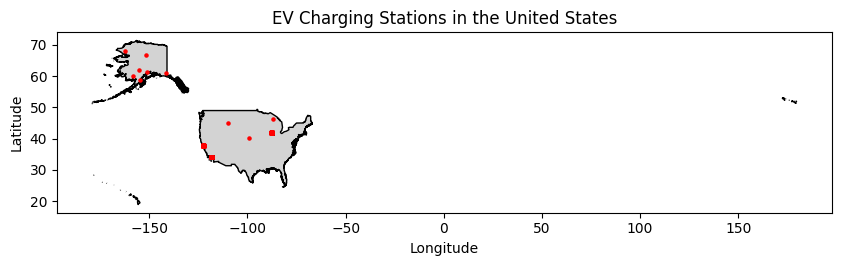

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,7))

us.plot(ax=ax, color="lightgray", edgecolor="black", aspect="auto")
stations_us.plot(ax=ax, color="red", markersize=5, aspect="auto")

plt.title("EV Charging Stations in the United States")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# limit dataset to San Francisco

In [12]:
lat_min, lat_max = 37.0, 38.5
lon_min, lon_max = -123.0, -121.0

sf_stations = stations_us[
    (stations_us["Latitude"] >= lat_min) &
    (stations_us["Latitude"] <= lat_max) &
    (stations_us["Longitude"] >= lon_min) &
    (stations_us["Longitude"] <= lon_max)
].copy()

print("Stations in SF region:", len(sf_stations))

Stations in SF region: 143


In [ ]:
sf_stations.drop(columns=["geometry", "index_right"], errors="ignore").to_csv(
    "../dataset/sf_charging_stations.csv",
    index=False
)

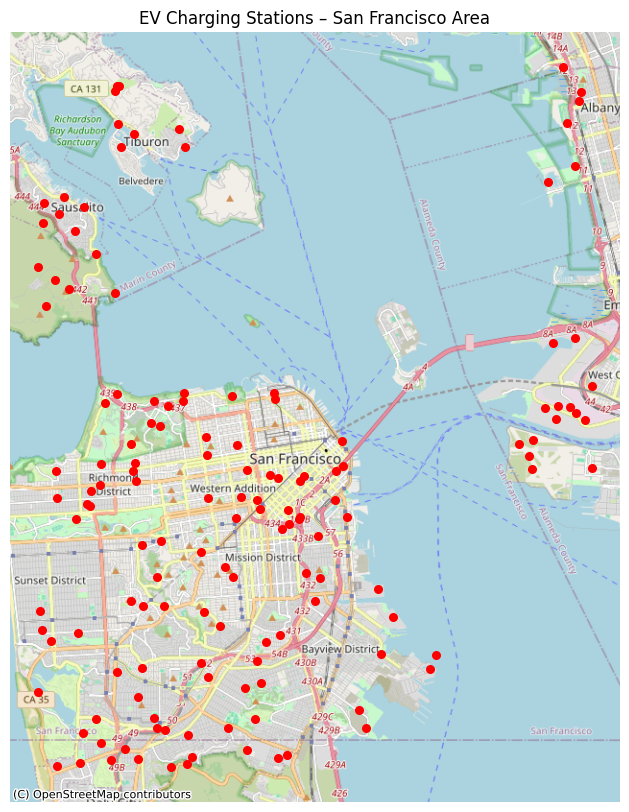

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    sf_stations,
    geometry=gpd.points_from_xy(sf_stations["Longitude"], sf_stations["Latitude"]),
    crs="EPSG:4326"
)

# Web maps require Web Mercator
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(ax=ax, color="red", markersize=30)

# Add OpenStreetMap background
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()

plt.title("EV Charging Stations – San Francisco Area")
plt.show()

# generate customers inside the station region

In [33]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_customers = 30
max_attempts = 1000

station_coords = sf_stations[["Latitude", "Longitude"]].to_numpy()

generated = []

lat_min, lat_max = sf_stations["Latitude"].min(), sf_stations["Latitude"].max()
lon_min, lon_max = sf_stations["Longitude"].min(), sf_stations["Longitude"].max()

while len(generated) < n_customers and max_attempts > 0:
    max_attempts -= 1

    base_idx = np.random.randint(len(station_coords))
    base_lat, base_lon = station_coords[base_idx]

    lat = base_lat + np.random.normal(0, 0.008)
    lon = base_lon + np.random.normal(0, 0.008)

    # keep only points still inside the SF study bounds
    if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
        generated.append((lat, lon))

customers = pd.DataFrame(generated, columns=["Latitude", "Longitude"])
customers.insert(0, "Customer ID", [f"C{i+1:03d}" for i in range(len(customers))])

customers.head()

,Customer ID,Latitude,Longitude
0,C001,37.757072,-122.437328
1,C002,37.777084,-122.326518
2,C003,37.794294,-122.318284
3,C004,37.723398,-122.419443
4,C005,37.737100,-122.433325


In [34]:
depot = pd.DataFrame({
    "Node ID": ["DEPOT"],
    "Latitude": [37.7749],
    "Longitude": [-122.4194],
    "Node Type": ["Depot"]
})

In [35]:
# choose a subset of charging stations for the instance
stations_instance = sf_stations.sample(n=10, random_state=42).copy()

print(len(stations_instance))
stations_instance.head()

10


,Station ID,Latitude,Longitude,Address,Charger Type,Cost (USD/kWh),Availability,Distance to City (km),Usage Stats (avg users/day),Station Operator,...,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA
4329,EVS04330,37.792768,-122.390718,"2485 San Francisco Ave, San Francisco",AC Level 1,0.44,9:00-18:00,14.32,33,ChargePoint,...,None,None,None,None,None,None,None,None,None,None
825,EVS00826,37.882773,-122.310383,"4890 San Francisco Ave, San Francisco",AC Level 1,0.33,24/7,8.14,93,Ionity,...,None,None,None,None,None,None,None,None,None,None
3162,EVS03163,37.789011,-122.439273,"710 San Francisco Ave, San Francisco",AC Level 1,0.34,24/7,7.37,38,Tesla,...,None,None,None,None,None,None,None,None,None,None
3729,EVS03730,37.747525,-122.400366,"9059 San Francisco Ave, San Francisco",DC Fast Charger,0.24,6:00-22:00,5.67,95,Tesla,...,None,None,None,None,None,None,None,None,None,None
2173,EVS02174,37.784671,-122.424967,"6911 San Francisco Ave, San Francisco",AC Level 2,0.23,24/7,7.49,66,Greenlots,...,None,None,None,None,None,None,None,None,None,None


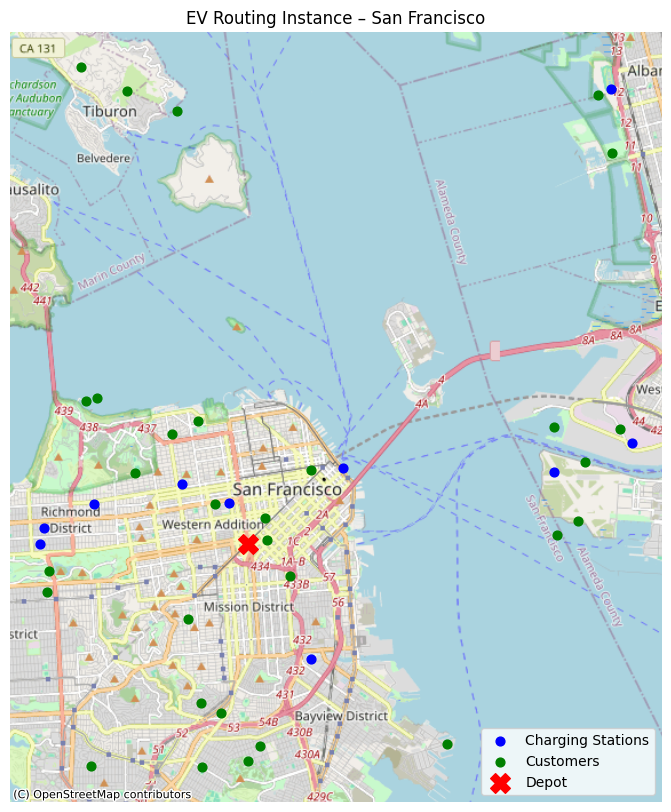

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Convert charging stations to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    stations_instance,
    geometry=gpd.points_from_xy(stations_instance["Longitude"], stations_instance["Latitude"]),
    crs="EPSG:4326"
)

# Convert customers
customers_gdf = gpd.GeoDataFrame(
    customers,
    geometry=gpd.points_from_xy(customers["Longitude"], customers["Latitude"]),
    crs="EPSG:4326"
)

# Convert depot
depot_gdf = gpd.GeoDataFrame(
    depot,
    geometry=gpd.points_from_xy(depot["Longitude"], depot["Latitude"]),
    crs="EPSG:4326"
)

# Convert to Web Mercator for map tiles
stations_gdf = stations_gdf.to_crs(epsg=3857)
customers_gdf = customers_gdf.to_crs(epsg=3857)
depot_gdf = depot_gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10,10))

stations_gdf.plot(
    ax=ax,
    color="blue",
    markersize=40,
    label="Charging Stations"
)

customers_gdf.plot(
    ax=ax,
    color="green",
    markersize=40,
    label="Customers"
)

depot_gdf.plot(
    ax=ax,
    color="red",
    marker="X",
    markersize=200,
    label="Depot"
)

# Add OpenStreetMap background
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()

plt.title("EV Routing Instance – San Francisco")
plt.legend()

plt.show()